<h1><center>NOVA IMS — Information Management School</center></h1>
<h2><center>Text Mining — Spring Semester 2025/2026</center></h2>
<h2><center>Final Project: Market Sentiment Classification of Financial Tweets</center></h2>

<center><b>Group 12</b></center>

| Name | Student № |
|------|-----------|
| João Cardoso | 20240529 |
| Simon Sazonov | 20221689 |
| Artem Polikarpov | 20250443 |


## Problem Statement

### Business Context

Financial markets move on information, and a growing share of that information first surfaces on social media. Company news, analyst actions, earnings surprises and macro events are discussed on platforms like Twitter/X minutes — sometimes hours — before they are fully reflected in prices. The aggregate mood of this conversation is what practitioners call **market sentiment**: optimism that prices will rise (**bullish**) or pessimism that they will fall (**bearish**).

Investment firms, trading desks and financial-data providers monitor this stream because sentiment carries actionable signal:

1. **Signal generation** — shifts in sentiment around a ticker can anticipate price moves and feed systematic trading strategies.
2. **Risk monitoring** — a surge of bearish chatter around a holding is an early warning that manual monitoring would catch too late.
3. **Market intelligence** — sentiment indices aggregated from social media contextualize fundamentals and complement traditional news analytics.

The challenge is scale: thousands of finance-related tweets are published every minute, far beyond what human analysts can read and tag. Turning this raw stream into a usable sentiment signal requires an automated NLP solution.

### Problem Definition

We are given a corpus of finance-related tweets, each manually labelled as **Bearish (0)**, **Bullish (1)** or **Neutral (2)**. The goal is to build a classification model that receives a tweet as input and predicts its sentiment class.

Concretely, this notebook must:

1. explore and understand the corpus (data exploration);
2. split it into train/validation/test for unbiased model selection (corpus split);
3. clean and normalize the text (preprocessing);
4. represent tweets numerically via Bag-of-Words, word2vec and Transformer-encoder features (feature engineering);
5. train and compare traditional ML and Transformer-encoder classifiers (classification models);
6. evaluate them with Precision, Recall, Accuracy and F1-Score and interpret the results in the context of the problem (evaluation).

The selected final model is then re-implemented as a single pipeline in `tm_final_12.ipynb` and used to predict the unlabelled test set, producing `pred_12.csv`.

### Data Dictionary

**`train.csv`** — 9,543 labelled tweets:

- **text**: the raw tweet, including cashtags (`$AAPL`), hashtags, @mentions, URLs, percentages and dollar amounts.
- **label**: the sentiment class — `0` = Bearish, `1` = Bullish, `2` = Neutral.

**`test.csv`** — 2,388 unlabelled tweets:

- **id**: tweet identifier, used as the `id` column of the submission file `pred_12.csv`.
- **text**: the raw tweet, same structure as in train.

*(The handout mentions 299 test rows; the distributed file contains 2,388 — verified in Data Import — and predictions cover all of them.)*

## About this notebook

This notebook follows this pipeline: data exploration → split → preprocessing → feature engineering (BoW, word2vec, Transformer encoder) → classification (traditional ML + Transformer encoders) → evaluation, plus the extra work (decoder-for-classification, agentic workflow) and a theory-grounded synthesis.

**Environment:** free/local tools only; all code runs on CPU, and a GPU is used automatically when available. All expensive steps are cached to `cache/` and reload on re-run, so re-executing the notebook never recomputes them.

## 0. Setup

Imports, seeds, config, caching and shared evaluation helpers.


In [1]:
import os, re, json, string, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # text bars: no widget state in saved outputs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)


In [2]:
# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
try:
    import torch
    torch.manual_seed(RANDOM_STATE)
except ImportError:
    pass


In [3]:
# Global config
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # keep download bars out of saved outputs
os.environ["KERAS_BACKEND"] = "torch"  # single DL framework: Keras (BiLSTM) runs on PyTorch, no TensorFlow needed
DATA_DIR  = "./data/"          # folder with train.csv / test.csv 
CACHE_DIR = "cache"
REPORT_FIG = "report/figures"   # figures used by report_12 are generated by THIS notebook
for d in (CACHE_DIR, REPORT_FIG):
    os.makedirs(d, exist_ok=True)

GROUP_ID = "12"

LABELS       = [0, 1, 2]
LABEL_NAMES  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
TARGET_NAMES = [LABEL_NAMES[i] for i in LABELS]

# Local secrets from .env (gitignored): HF_TOKEN lifts anonymous HF rate limits
from dotenv import load_dotenv
load_dotenv()


True

In [4]:
# Caching helper
import joblib

def cache_path(name): return os.path.join(CACHE_DIR, name)

def load_or_build(name, build_fn):
    """Load `name` from cache if present; otherwise build, save and return it."""
    path = cache_path(name)
    ext  = os.path.splitext(name)[1].lower()
    if os.path.exists(path):
        print(f"[cache] load  {name}")
        if ext == ".npy":              return np.load(path, allow_pickle=True)
        if ext in (".joblib", ".pkl"): return joblib.load(path)
        if ext == ".json":
            with open(path) as f:      return json.load(f)
    print(f"[cache] build {name} ...")
    obj = build_fn()
    if ext == ".npy":              np.save(path, obj)
    elif ext in (".joblib", ".pkl"): joblib.dump(obj, path)
    elif ext == ".json":
        with open(path, "w") as f: json.dump(obj, f, indent=2)
    return obj


In [5]:
# Shared evaluation utilities
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, balanced_accuracy_score, matthews_corrcoef)

RESULTS = []

def classification_metrics(y_true, y_pred):
    """One-row DataFrame of overall metrics — concat rows to compare models side by side."""
    rep = classification_report(y_true, y_pred, labels=LABELS, target_names=TARGET_NAMES,
                                output_dict=True, zero_division=0)
    return pd.DataFrame({
        "Accuracy":        rep["accuracy"],
        "Macro Precision": rep["macro avg"]["precision"],
        "Macro Recall":    rep["macro avg"]["recall"],
        "Macro F1":        rep["macro avg"]["f1-score"],
        "Weighted F1":     rep["weighted avg"]["f1-score"],
        "Balanced Acc":    balanced_accuracy_score(y_true, y_pred),
        "MCC":             matthews_corrcoef(y_true, y_pred),
    }, index=[0])

def evaluate(y_true, y_pred, feature_name, model_name, log=True, show=True):
    """Per-class report + metrics logged to RESULTS. Macro-F1 is the headline metric (imbalanced classes)."""
    rep = classification_report(y_true, y_pred, labels=LABELS, target_names=TARGET_NAMES,
                                output_dict=True, zero_division=0)
    overall = classification_metrics(y_true, y_pred).iloc[0]
    if show:
        print(classification_report(y_true, y_pred, labels=LABELS,
              target_names=TARGET_NAMES, zero_division=0))
        print(f"Accuracy: {overall['Accuracy']:.4f}  |  Macro-F1: {overall['Macro F1']:.4f}  |  "
              f"Balanced acc: {overall['Balanced Acc']:.4f}  |  MCC: {overall['MCC']:.4f}")
    if log:
        row = {"feature": feature_name, "model": model_name,
               "macro_f1": overall["Macro F1"], "accuracy": overall["Accuracy"],
               "weighted_f1": overall["Weighted F1"],
               "balanced_acc": overall["Balanced Acc"], "mcc": overall["MCC"]}
        for name in TARGET_NAMES:
            row[f"f1_{name.lower()}"]        = rep[name]["f1-score"]
            row[f"recall_{name.lower()}"]    = rep[name]["recall"]
            row[f"precision_{name.lower()}"] = rep[name]["precision"]
        RESULTS.append(row)
    return overall["Macro F1"]

def plot_confusion(y_true, y_pred, title):
    """Confusion-matrix heatmap annotated with counts and row percentages (recall per true class)."""
    cm  = confusion_matrix(y_true, y_pred, labels=LABELS)
    pct = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([f"{c}\n{p:.1%}" for c, p in zip(cm.flatten(), pct.flatten())]).reshape(cm.shape)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    plt.ylabel("True label"); plt.xlabel("Predicted label"); plt.title(title)
    plt.tight_layout(); plt.show()


In [6]:
# Reusable plotting helpers
def labeled_barplot(data, feature, perc=False, n=None, save=None):
    """Barplot of a categorical column, each bar labeled with its count (or percentage if perc=True)."""
    total = len(data[feature])
    n_categories = data[feature].nunique()
    plt.figure(figsize=((n or n_categories) + 1, 5))
    order = data[feature].value_counts().index[:n].sort_values()
    ax = sns.countplot(data=data, x=feature, hue=feature, legend=False,
                       palette="Paired", order=order)
    for patch in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * patch.get_height() / total)
        else:
            label = int(patch.get_height())
        ax.annotate(label,
                    (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                    ha="center", va="center", size=12,
                    xytext=(0, 5), textcoords="offset points")
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

def histogram_boxplot(data, feature, figsize=(10, 5), kde=False, bins=None):
    """Histogram with a boxplot on a shared x-axis (dashed green = mean, black = median)."""
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=figsize)
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=kde, bins=bins or "auto", ax=ax_hist)
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-")
    plt.show()


In [7]:
# NLTK resources
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

STOP    = set(stopwords.words("english"))
LEMMA   = WordNetLemmatizer()
STEMMER = SnowballStemmer("english")


## 1. Data Import

### Observe the Data


In [8]:
def read_csv_safe(path):
    for enc in ["utf-8", "latin-1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", engine="python")

train_df = read_csv_safe(os.path.join(DATA_DIR, "train.csv"))
test_df  = read_csv_safe(os.path.join(DATA_DIR, "test.csv"))

print("train shape:", train_df.shape, "| test shape:", test_df.shape)
print("train columns:", list(train_df.columns))
print("test  columns:", list(test_df.columns))
train_df.head()


train shape: (9543, 2) | test shape: (2388, 2)
train columns: ['text', 'label']
test  columns: ['id', 'text']


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [9]:
# Sanity checks
assert "text" in train_df.columns and "label" in train_df.columns, \
    f"Expected 'text' & 'label' in train; got {list(train_df.columns)}"
assert "text" in test_df.columns, f"Expected 'text' in test; got {list(test_df.columns)}"

print("Labels present in train:", sorted(train_df["label"].dropna().unique()))
print("Null text (train):", int(train_df["text"].isna().sum()))
print("Empty text (train):", int((train_df["text"].astype(str).str.strip() == "").sum()))
print("Exact duplicate tweets (train):", int(train_df["text"].duplicated().sum()))


Labels present in train: [np.int64(0), np.int64(1), np.int64(2)]
Null text (train): 0
Empty text (train): 0
Exact duplicate tweets (train): 0


In [10]:
# test.csv's 'id' column becomes the 'id' column of the submission file pred_12.csv
assert "id" in test_df.columns, f"expected an 'id' column in test.csv; got {list(test_df.columns)}"
test_df["id"].head(3)


0    0
1    1
2    2
Name: id, dtype: int64

In [11]:
# Drop null/empty/duplicate tweets BEFORE splitting — dedup after the split could leave the same tweet in two splits
before = len(train_df)
train_df = train_df.dropna(subset=["text"])
train_df = train_df[train_df["text"].astype(str).str.strip() != ""]
train_df = train_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Dropped {before - len(train_df)} null/empty/duplicate rows -> train now {len(train_df)}")


Dropped 0 null/empty/duplicate rows -> train now 9543


**Observations:**

- 9,543 training rows (`text`, `label`), labels exactly `{0,1,2}`; no nulls, empty strings or duplicates — nothing to drop, no train/validation leakage risk from repeats.
- `test.csv` has **2,388 rows** (`id`, `text`), not the 299 the handout mentions; its explicit `id` column is used directly in `pred_12.csv`.


## 2. Exploratory Analysis


### Label (Dependent Feature)


Class distribution (train):
  0 Bearish :  1442  ( 15.1%)
  1 Bullish :  1923  ( 20.2%)
  2 Neutral :  6178  ( 64.7%)

Majority class: 2 (Neutral)
Majority-class ACCURACY : 0.6474
Majority-class MACRO-F1 : 0.2620


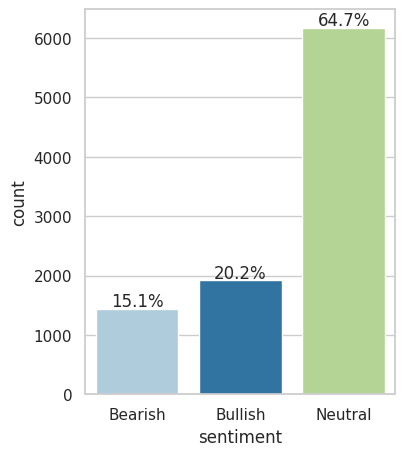

In [12]:
counts = train_df["label"].value_counts().sort_index()
total  = len(train_df)
print("Class distribution (train):")
for lbl in LABELS:
    c = int(counts.get(lbl, 0))
    print(f"  {lbl} {LABEL_NAMES[lbl]:<8}: {c:>5}  ({c/total*100:5.1f}%)")

maj          = int(counts.idxmax())
maj_acc      = counts.max() / total
y_all        = train_df["label"].values
maj_macro_f1 = f1_score(y_all, np.full_like(y_all, maj), average="macro")
print(f"\nMajority class: {maj} ({LABEL_NAMES[maj]})")
print(f"Majority-class ACCURACY : {maj_acc:.4f}")
print(f"Majority-class MACRO-F1 : {maj_macro_f1:.4f}")

plot_df = train_df.assign(sentiment=train_df["label"].map(LABEL_NAMES))
labeled_barplot(plot_df, "sentiment", perc=True, save=f"{REPORT_FIG}/label_distribution.png")


**Observations:**

- Strong imbalance: **Neutral 64.7%** (6,178), **Bullish 20.2%** (1,923), **Bearish 15.1%** (1,442).
- Always-predict-Neutral scores **0.647 accuracy** but only **0.262 macro-F1** (F1 = 0 on Bearish and Bullish) — accuracy alone is misleading on this data.

**Conclusions:**

- Headline metric = **macro-F1**; accuracy is reported but never used for model selection.
- Stratified train/validation/test split; stratified 5-fold CV for finalist tuning.
- `class_weight='balanced'` on Logistic Regression; class-weight dict on the BiLSTM.
- For every model, watch Bearish/Bullish recall and the confusion matrix.


### Text (Independent Features) — Word Clouds by Sentiment

Most frequent words per class (throwaway tokenisation, for visualisation only — real preprocessing comes later).


Shared across all sentiments (excluded from clouds): ['china', 'deal', 'earnings', 'economy', 'energy', 'funds', 'inc', 'market', 'markets', 'marketscreener', 'new', 'oil', 'price', 'says', 'stock', 'stocks', 'trade', 'update', 'year'] 

[Bearish] top words: ['misses', 'coronavirus', 'shares', 'cut', 'revenue', 'sales', 'lower', 'target', 'eps', 'hedge', 'cuts', 'falls', 'growth', 'downgraded', 'report']


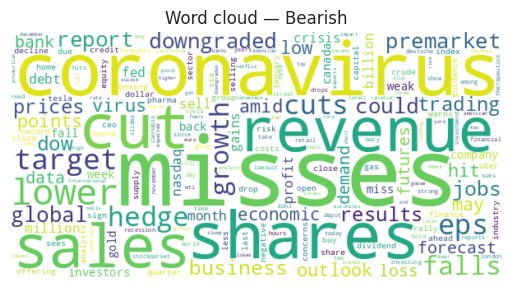

[Bullish] top words: ['beats', 'target', 'shares', 'revenue', 'eps', 'raised', 'higher', 'buy', 'hedge', 'bullish', 'nasdaq', 'high', 'growth', 'sales', 'dow']


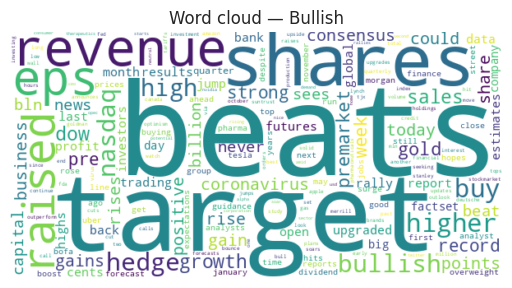

[Neutral] top words: ['results', 'dividend', 'reports', 'call', 'declares', 'fed', 'trump', 'buy', 'ceo', 'conference', 'presentation', 'billion', 'bank', 'transcript', 'nasdaq']


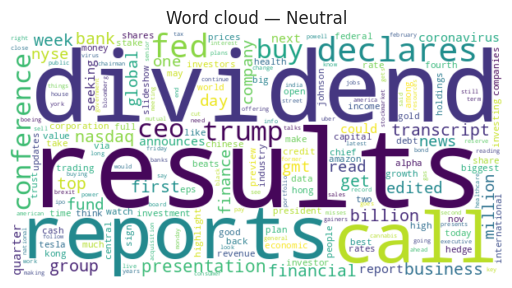

In [13]:
from collections import Counter
from wordcloud import WordCloud

def quick_tokens(s):
    s = re.sub(r"http\S+", "", str(s).lower())
    s = re.sub(r"[^a-z\s]", " ", s)
    return [w for w in s.split() if w not in STOP and len(w) > 2]

class_counts = {lbl: Counter(t for s in train_df.loc[train_df["label"] == lbl, "text"]
                             for t in quick_tokens(s)) for lbl in LABELS}

# Words in the top-50 of ALL three classes are corpus-wide vocabulary, not sentiment signal.
# Excluded from the clouds only — models still see the full text (TF-IDF down-weights them).
top50 = [{w for w, _ in c.most_common(50)} for c in class_counts.values()]
DOMAIN_COMMON = set.intersection(*top50)
print("Shared across all sentiments (excluded from clouds):", sorted(DOMAIN_COMMON), "\n")

uni_cloud_img = {}
for lbl in LABELS:
    counts = {w: k for w, k in class_counts[lbl].items() if w not in DOMAIN_COMMON}
    top = sorted(counts, key=counts.get, reverse=True)[:15]
    print(f"[{LABEL_NAMES[lbl]}] top words: {top}")
    wc = WordCloud(width=600, height=300, background_color="white").generate_from_frequencies(counts)
    uni_cloud_img[lbl] = wc.to_array()
    plt.figure(figsize=(7, 3.2)); plt.imshow(wc, interpolation="bilinear")
    plt.axis("off"); plt.title(f"Word cloud — {LABEL_NAMES[lbl]}"); plt.show()


**Observations:**

- 19 words are top-frequency in **all three** classes (*stock(s), market(s), economy, china, trade, oil, price, earnings, marketscreener, …*) — corpus-wide vocabulary with no sentiment signal, excluded from the clouds to expose what differs.
- **Bearish:** *misses, cut, cuts, lower, falls, downgraded, coronavirus* — downgrade/miss language and crisis terms.
- **Bullish:** *beats, raised, higher, buy, bullish, target, eps* — earnings-beat and upgrade language.
- **Neutral:** *results, reports, declares, dividend, call, conference, presentation, transcript* — factual corporate-calendar language.
- Vocabulary is clearly class-separable → expect a competitive TF-IDF + Logistic Regression baseline.
- Risk: company/vendor names among the top tokens — a model could learn *names* rather than *sentiment*; cashtags are normalised to a generic `ticker` token in Preprocessing.


### Text (Independent Features) — Bigram Clouds by Sentiment


Shared across all sentiments (excluded from clouds): ['economy marketscreener', 'fourth quarter', 'hedge funds', 'market update', 'new york', 'seeking alpha', 'share price', 'stock market', 'stock marketscreener', 'trade deal', 'wall street'] 

[Bearish] top bigrams: ['misses revenue', 'eps misses', 'misses misses', 'price target', 'stock price', 'target cut', 'equity offering', 'stock falls', 'deutsche bank', 'home depot', 'credit suisse', 'roundup economy', 'oil prices', 'funds dumping', 'funds selling']


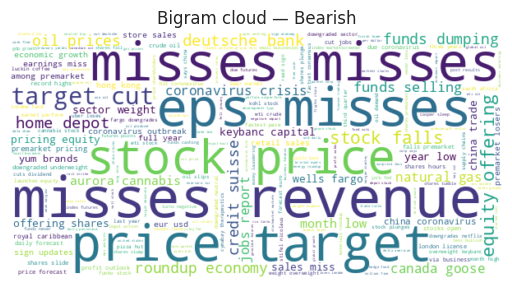

[Bullish] top bigrams: ['price target', 'stock price', 'target raised', 'beats revenue', 'beats beats', 'eps beats', 'funds never', 'never bullish', 'factset consensus', 'morgan stanley', 'china trade', 'year ago', 'bofa merrill', 'merrill lynch', 'shares jump']


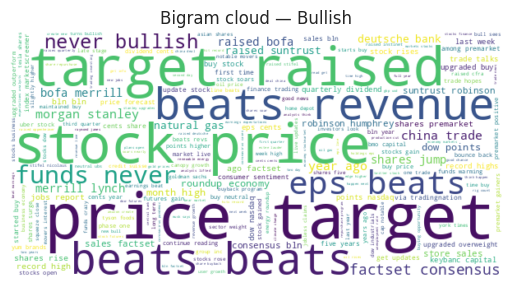

[Neutral] top bigrams: ['reports results', 'declares dividend', 'call presentation', 'conference call', 'earnings conference', 'edited transcript', 'presentation nov', 'nov gmt', 'earnings call', 'results earnings', 'hong kong', 'earnings preview', 'inc nasdaq', 'stock buy', 'call transcript']


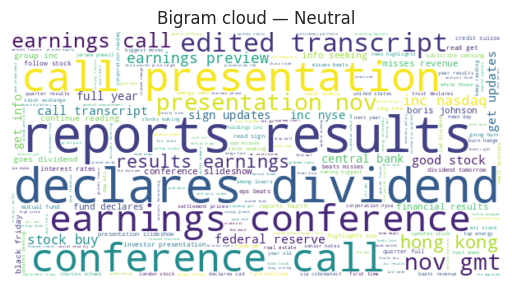

In [14]:
bigram_counts = {}
for lbl in LABELS:
    c = Counter()
    for s in train_df.loc[train_df["label"] == lbl, "text"]:
        toks = quick_tokens(s)
        c.update(" ".join(p) for p in zip(toks, toks[1:]))
    bigram_counts[lbl] = c

# Same filter as the unigram clouds: bigrams in the top-50 of ALL three classes are boilerplate
top50 = [{b for b, _ in c.most_common(50)} for c in bigram_counts.values()]
BIGRAM_COMMON = set.intersection(*top50)
print("Shared across all sentiments (excluded from clouds):", sorted(BIGRAM_COMMON), "\n")

bigram_cloud_img = {}
for lbl in LABELS:
    counts = {b: k for b, k in bigram_counts[lbl].items() if b not in BIGRAM_COMMON}
    top = sorted(counts, key=counts.get, reverse=True)[:15]
    print(f"[{LABEL_NAMES[lbl]}] top bigrams: {top}")
    wc = WordCloud(width=600, height=300, background_color="white").generate_from_frequencies(counts)
    bigram_cloud_img[lbl] = wc.to_array()
    plt.figure(figsize=(7, 3.2)); plt.imshow(wc, interpolation="bilinear")
    plt.axis("off"); plt.title(f"Bigram cloud — {LABEL_NAMES[lbl]}"); plt.show()


**Observations:**

- 11 bigrams are top-frequency in all three classes — news/source boilerplate (*economy marketscreener, market update, stock market, wall street, seeking alpha, hedge funds*) — and are excluded as before.
- **Bearish:** *misses revenue, eps misses, target cut, stock falls, equity offering* — analyst-action and earnings-miss phrasing.
- **Bullish:** *target raised, beats revenue, eps beats, price target* — the mirror image of Bearish.
- **Neutral:** *reports results, declares dividend, conference call, earnings conference, edited transcript* — corporate-calendar/event phrasing.

**Conclusions:**

- Bearish and Bullish share the same phrase stems with opposite verbs (*target cut* vs *target raised*; *misses revenue* vs *beats revenue*): the sentiment lives in short word pairs, a direct argument for including **n-grams in the BoW/TF-IDF features**.


In [15]:
# Composite of the six clouds above (unigram | bigram per class) — the figure used in report Section 1
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for r, lbl in enumerate(LABELS):
    for k, (img, kind) in enumerate([(uni_cloud_img[lbl], "words"), (bigram_cloud_img[lbl], "bigrams")]):
        axes[r, k].imshow(img); axes[r, k].axis("off")
        axes[r, k].set_title(f"{LABEL_NAMES[lbl]} — {kind}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{REPORT_FIG}/clouds_grid.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("saved report/figures/clouds_grid.png")


saved report/figures/clouds_grid.png


### Financial-domain Signals

How often finance-specific tokens (cashtags, `%`, `$`, hashtags, mentions, URLs) appear in each class.


Fraction of tweets containing each signal, by class (%):
         cashtag  percent  money  hashtag  mention   url  number  allcaps
Bearish     13.8     16.3   10.1      6.8      2.1  44.3    37.9     40.8
Bullish     25.1     21.2   16.5      6.2      1.6  39.1    47.7     48.5
Neutral     12.2      3.1    9.4     11.0      3.8  49.8    29.8     41.5


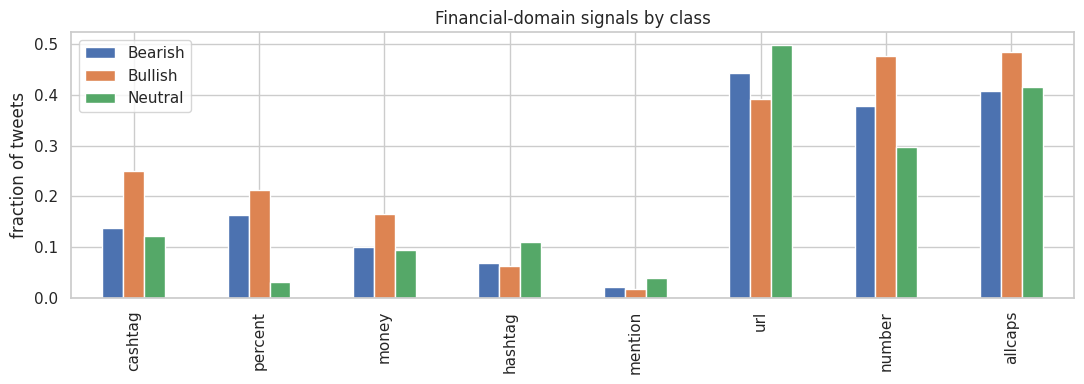

In [16]:
patterns = {
    "cashtag": r"\$[A-Za-z]{1,6}\b",
    "percent": r"\d+(?:\.\d+)?\s?%",
    "money":   r"\$\d+(?:[.,]\d+)?[kKmMbB]?\b",
    "hashtag": r"#\w+",
    "mention": r"@\w+",
    "url":     r"http\S+|www\.\S+",
    "number":  r"\b\d+(?:[.,]\d+)?\b",
    "allcaps": r"\b[A-Z]{2,}\b",
}
rows = []
for lbl in LABELS:
    texts = train_df.loc[train_df["label"] == lbl, "text"].astype(str)
    rows.append({name: texts.str.contains(pat, regex=True).mean()
                 for name, pat in patterns.items()})
sig = pd.DataFrame(rows, index=[LABEL_NAMES[l] for l in LABELS])
print("Fraction of tweets containing each signal, by class (%):")
print((sig * 100).round(1))

sig.T.plot(kind="bar", figsize=(11, 4))
plt.ylabel("fraction of tweets"); plt.title("Financial-domain signals by class")
plt.tight_layout(); plt.savefig(f"{REPORT_FIG}/domain_signals.png", dpi=150, bbox_inches="tight"); plt.show()


**Observations:**

- **Percentages** are the sharpest discriminator: 21.2% of Bullish and 16.3% of Bearish tweets vs **3.1%** of Neutral — directional moves (`+5%`, `−8%`) signal opinion.
- Cashtags lean Bullish (25.1% vs ~13% elsewhere); numbers likewise (47.7% vs 29.8% Neutral).
- Neutral is the most news-like: highest URL (49.8%), hashtag (11.0%) and @mention (3.8%) rates.

**Conclusions:**

- Deleting every digit/`%`/`$` (the lab default) would erase real signal — Preprocessing therefore normalises these tokens (`ticker`/`pct`/`num`) and keeps negation words, instead of applying the lab-style letters-only cleaner.


### Tweet Length Distribution *(v2 addition)*


Characters per tweet : {'count': 9543.0, 'mean': 85.8, 'std': 35.1, 'min': 2.0, '25%': 58.0, '50%': 79.0, '75%': 120.0, 'max': 190.0}
Tokens per tweet     : {'count': 9543.0, 'mean': 12.2, 'std': 4.7, 'min': 1.0, '25%': 9.0, '50%': 11.0, '75%': 15.0, 'max': 32.0}
Token percentiles    : {'p50': 11, 'p90': 19, 'p95': 21, 'p99': 23}


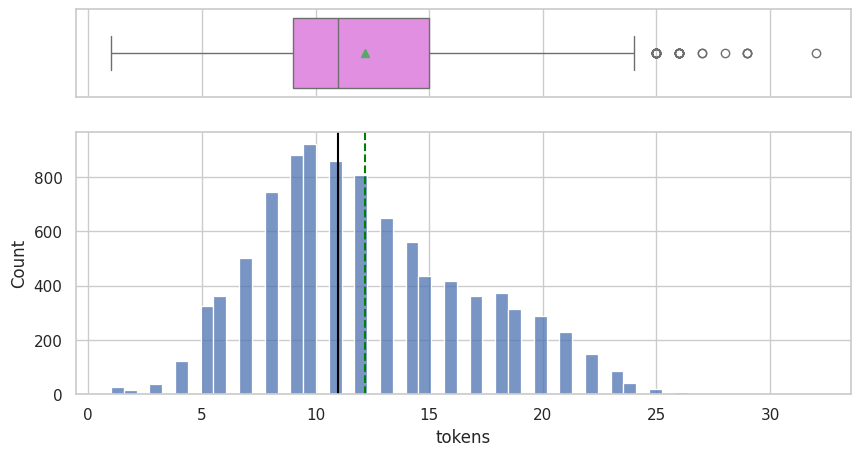

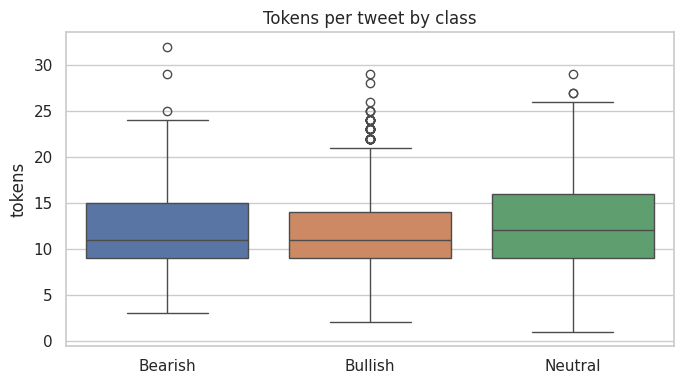

In [17]:
length_df = pd.DataFrame({
    "tokens":    train_df["text"].astype(str).str.split().str.len(),
    "sentiment": train_df["label"].map(LABEL_NAMES),
})
print("Characters per tweet :", train_df["text"].astype(str).str.len().describe().round(1).to_dict())
print("Tokens per tweet     :", length_df["tokens"].describe().round(1).to_dict())
print("Token percentiles    :", {f"p{p}": int(np.percentile(length_df["tokens"], p)) for p in [50, 90, 95, 99]})

histogram_boxplot(length_df, "tokens")
plt.figure(figsize=(7, 4))
sns.boxplot(data=length_df, x="sentiment", y="tokens", hue="sentiment", legend=False, palette="deep")
plt.title("Tokens per tweet by class"); plt.xlabel(""); plt.tight_layout(); plt.show()


**Observations:**

- Tweets are short and uniform: median **11 tokens** (mean 12.2, max 32); class medians 11–12, so length separates nothing by itself.
- Tail: p95 = 21, p99 = 23, max = 32 → **`max_len = 32`** word-tokens covers every tweet with zero truncation (transformer `max_length` gets headroom for subword expansion).


### Conclusion — Exploratory Analysis

1. **Imbalance (65/20/15)** ⇒ macro-F1 headline, stratified split + CV, class weighting, watch minority recall. (Baseline to beat: macro-F1 **0.262**.)
2. **Strong lexical separability** ⇒ expect a competitive TF-IDF baseline; contextual models should help but maybe not dramatically (tweets are short).
3. **Domain tokens carry signal** (esp. `%`) ⇒ normalise `ticker`/`pct`/`num` and keep negation words instead of letters-only cleaning.
4. **Name/ticker leakage risk** ⇒ normalise cashtags to a generic token so the model learns sentiment, not specific tickers.


## 3. Corpus Split

Stratified **70/15/15 train/validation/test** split. `test.csv` is unlabelled (submission only), so the internal test split provides the final unbiased estimate: models are selected on validation, the chosen model is scored once on test, and the submission model is retrained on all rows. Anything that learns parameters (vectorizers, scalers) is fit on train only.


In [18]:
from sklearn.model_selection import train_test_split

X = train_df["text"].reset_index(drop=True)
y = train_df["label"].reset_index(drop=True)

# 15% held-out internal test, then 15% of the total as validation -> 70/15/15
X_tmp_raw, X_test_raw, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.15 / 0.85, random_state=RANDOM_STATE, stratify=y_tmp)

print(f"train: {len(X_train_raw)}  |  val: {len(X_val_raw)}  |  test: {len(X_test_raw)}")
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    d = yy.value_counts(normalize=True).sort_index()
    print(name, {LABEL_NAMES[k]: round(v * 100, 1) for k, v in d.items()})


train: 6679  |  val: 1432  |  test: 1432
train {'Bearish': 15.1, 'Bullish': 20.1, 'Neutral': 64.7}
val {'Bearish': 15.1, 'Bullish': 20.2, 'Neutral': 64.7}
test {'Bearish': 15.1, 'Bullish': 20.2, 'Neutral': 64.7}


**Observations:**

- **6,679 train / 1,432 validation / 1,432 test**; class proportions preserved in all three splits (15.1 / 20.1–20.2 / 64.7).
- Minority classes stay well represented per split (validation: Bearish n=216, Bullish n=289; test: Bearish n=216, Bullish n=289), so per-class metrics are stable.
- All models are compared on the identical validation split; the internal test split is touched once, by the selected final model.


## 4. Preprocessing

Each technique below is a small named function demonstrated on sample tweets; they then compose into one finance-aware cleaner, chosen by the rationale from the Exploratory Analysis. The cleaned text feeds the BoW and word2vec features only — transformer encoders receive raw text, since their subword tokenizers expect it.


### Removing URLs and Mentions

In [19]:
def remove_urls_mentions(text):
    """URLs and @mentions carry no sentiment (verified in Exploratory Analysis)."""
    text = re.sub(r"http\S+|www\.\S+", " ", str(text))
    return re.sub(r"@\w+", " ", text)

demo_ix = X_train_raw[X_train_raw.str.contains("http")].index[:3]
pd.DataFrame({"before": X_train_raw.loc[demo_ix],
              "after":  X_train_raw.loc[demo_ix].map(remove_urls_mentions)})


,before,after
2261,$DHF - BNY Mellon High Yield Strategies Fund declares $0.0215 dividend https://t.co/AH81aIYEqb,$DHF - BNY Mellon High Yield Strategies Fund declares $0.0215 dividend
8282,$TALKX: Market Briefing https://t.co/qKadK8u9pa,$TALKX: Market Briefing
3699,".@GitaGopinath: #COVID19 has pushed the world into recession. For 2020, the economic impact of COVID-19 will be wor… https://t.co/5zRk5aEX3G",". : #COVID19 has pushed the world into recession. For 2020, the economic impact of COVID-19 will be wor…"


- URLs and @mentions are removed; the remaining text is untouched.


### Normalising Financial Tokens

In [20]:
def normalize_financial(text):
    """Cashtags/percentages/numbers become placeholder tokens — the class signal they carry
    (Financial-domain Signals) survives cleaning without exploding the vocabulary."""
    text = re.sub(r"\$[a-zA-Z]{1,6}\b", " ticker ", str(text))
    text = re.sub(r"\d+(?:\.\d+)?\s?%", " pct ", text)
    return re.sub(r"\b\d+(?:[.,]\d+)?\s?[kmbtKMBT]?\b", " num ", text)

demo_ix = X_train_raw[X_train_raw.str.contains(r"%") & X_train_raw.str.contains(r"\$[A-Za-z]")].index[:3]
pd.DataFrame({"before": X_train_raw.loc[demo_ix],
              "after":  X_train_raw.loc[demo_ix].map(normalize_financial)})


,before,after
9215,$ORLY strong up 11.7% into large volume pocket w/ room to $360,ticker strong up pct into large volume pocket w/ room to $ num
8969,$TAL - TAL Education -23% after fraud disclosure https://t.co/rj4urxOYLD,ticker - TAL Education - pct after fraud disclosure https://t.co/rj4urxOYLD
9255,$WORK (+1.4% pre) Slack (WORK) Prices Upsized Offering of $750 Million 0.50% Convertible Senior Notes due 2025 - SI\n\nhttps://t.co/JdcEO6T5YW,ticker (+ pct pre) Slack (WORK) Prices Upsized Offering of $ num Million pct Convertible Senior Notes due num - SI\n\nhttps://t.co/JdcEO6T5YW


- `$TSLA` → `ticker`, `5%` → `pct`, bare numbers → `num`: one shared token per signal type instead of thousands of distinct strings.


### Lowercasing and Removing Special Characters

In [21]:
def keep_letters_only(text):
    return re.sub(r"[^a-zA-Z\s]", " ", str(text))

demo_ix = X_train_raw.index[:3]
pd.DataFrame({"before": X_train_raw.loc[demo_ix],
              "after":  X_train_raw.loc[demo_ix].map(lambda t: keep_letters_only(str(t).lower()))})


,before,after
2705,Edited Transcript of ESI.TO earnings conference call or presentation 12-Nov-19 9:00pm GMT,edited transcript of esi to earnings conference call or presentation nov pm gmt
2851,Northern Star Resources reports 1H results,northern star resources reports h results
308,Results: KLA Corporation Beat Earnings Expectations And Analysts Now Have New Forecasts,results kla corporation beat earnings expectations and analysts now have new forecasts


- Lowercasing collapses case variants into one token; letters-only stripping removes punctuation — and also digits, `%` and `$`, which is exactly what the aggressive variant does and the conservative variant avoids by normalising first.


### Removing Stop Words

In [22]:
# Standard stoplists remove negators, which can flip sentiment ("not bullish") — keep them optionally
NEG_WORDS = {"not","no","never","none","nobody","nothing","neither","nor","cannot",
             "cant","dont","doesnt","didnt","wont","isnt","arent","wasnt","without"}
STOP_KEEPNEG = STOP - NEG_WORDS

def remove_stopwords(text, keep_negation=True):
    stoplist = STOP_KEEPNEG if keep_negation else STOP
    return " ".join(w for w in str(text).split() if w not in stoplist)

demo_ix = X_train_raw[X_train_raw.str.lower().str.contains(r"\bnot\b")].index[:2]
demo = X_train_raw.loc[demo_ix].str.lower()
pd.DataFrame({"before": demo,
              "all stopwords removed": demo.map(lambda t: remove_stopwords(t, keep_negation=False)),
              "negation kept": demo.map(remove_stopwords)})


,before,all stopwords removed,negation kept
5797,wirecard says 2017 audit of singapore unit not concluded due to probe,wirecard says 2017 audit singapore unit concluded due probe,wirecard says 2017 audit singapore unit not concluded due probe
8098,"the corticeira amorim s.g.p.s (eli:cor) share price has gained 224%, so why not pay it some attention?","corticeira amorim s.g.p.s (eli:cor) share price gained 224%, pay attention?","corticeira amorim s.g.p.s (eli:cor) share price gained 224%, not pay attention?"


- The standard stoplist deletes *not/no/never*; the `keep_negation` variant preserves them so negated sentiment stays expressible.


### Stemming and Lemmatisation

In [23]:
def lemmatize_text(text):
    return " ".join(LEMMA.lemmatize(w) for w in str(text).split())

def stem_text(text):
    return " ".join(STEMMER.stem(w) for w in str(text).split())

demo = pd.Series(["shares raised after beating expectations",
                  "companies cutting losses amid falling prices"])
pd.DataFrame({"before": demo, "lemmatised": demo.map(lemmatize_text), "stemmed": demo.map(stem_text)})


,before,lemmatised,stemmed
0,shares raised after beating expectations,share raised after beating expectation,share rais after beat expect
1,companies cutting losses amid falling prices,company cutting loss amid falling price,compani cut loss amid fall price


- Lemmatisation maps inflections to dictionary forms (*shares* → *share*); stemming truncates harder (*raised* → *rais*, *companies* → *compani*), merging more forms at the cost of readability. Lemmatisation is adopted: it only ever produces dictionary words, which keeps the inspection of model features readable; the heavier merging of stemming is not needed on a corpus this small in vocabulary.


### Assembling the Cleaner

The techniques compose into one cleaner whose choices follow directly from the Exploratory Analysis: normalise rather than delete the finance tokens, keep negation, lemmatise.

In [24]:
def clean_text(texts):
    out = []
    for t in tqdm(texts, leave=False, desc="clean"):
        t = remove_urls_mentions(str(t).lower())
        t = normalize_financial(t)                 # BEFORE letters-only, so ticker/pct/num survive
        t = keep_letters_only(t)
        t = remove_stopwords(t, keep_negation=True)
        t = lemmatize_text(t)
        out.append(re.sub(r"\s+", " ", t).strip())
    return out

X_train_clean = load_or_build("clean_train.json", lambda: clean_text(list(X_train_raw)))
X_val_clean   = load_or_build("clean_val.json",   lambda: clean_text(list(X_val_raw)))
X_test_clean  = load_or_build("clean_test.json",  lambda: clean_text(list(X_test_raw)))

demo_ix = X_train_raw[X_train_raw.str.contains(r"%")].index[:3]
pd.DataFrame({"before": X_train_raw.loc[demo_ix],
              "after":  [X_train_clean[X_train_raw.index.get_loc(i)] for i in demo_ix]})


[cache] load  clean_train.json
[cache] load  clean_val.json
[cache] load  clean_test.json


,before,after
9215,$ORLY strong up 11.7% into large volume pocket w/ room to $360,ticker strong pct large volume pocket w room num
8969,$TAL - TAL Education -23% after fraud disclosure https://t.co/rj4urxOYLD,ticker tal education pct fraud disclosure
3414,BJ's Wholesale Q3 same-store sales up 1.1%; FactSet consensus up 2.0%,bj wholesale q store sale pct factset consensus pct


- The finance tokens survive as `ticker`/`pct`/`num`; URLs, mentions, punctuation and stop words are gone; words are in dictionary form.


### Conclusion — Preprocessing

1. **One finance-aware cleaner is adopted** for all BoW and word2vec features, composed of: URL/mention removal, financial-token normalisation, lowercasing, special-character removal, stop-word removal with negation kept, and lemmatisation.
2. **Normalise, don't delete**: the Exploratory Analysis measured that percentages appear in 21.2% of Bullish and 16.3% of Bearish tweets against 3.1% of Neutral — a letters-only cleaner would erase that signal, so cashtags, percentages and numbers become the placeholder tokens `ticker`/`pct`/`num` instead.
3. **`ticker` normalisation also protects generalisation**: it removes company identities a model could memorise, so what is learned is sentiment vocabulary, not company names.
4. **Negation is kept** (*not*, *no*, *never*, …) because standard stoplists would delete it and negation can flip sentiment ("not bullish").
5. **Lemmatisation over stemming**: dictionary forms keep later feature inspection readable; stemming's harder merging is unnecessary here.
6. **Transformer encoders receive raw text** — their subword tokenizers handle casing and punctuation natively.
7. Techniques implemented: regex normalisation (URLs, mentions, cashtags, percentages, numbers), lowercasing, special-character removal, stop-word removal, lemmatisation, stemming — six, against the four required.


## 5. Feature Engineering

Three representation families: Bag-of-Words on the cleaned text, word2vec trained on the training split, and transformer sentence embeddings on raw text. Vectorizers are defined here and fit inside the model pipelines later (train folds only); dense representations are precomputed once and cached.

### Bag-of-Words (BoW)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

BOW_VARIANTS = {
    "counts":          CountVectorizer(min_df=2),
    "tfidf":           TfidfVectorizer(min_df=2),
    "tfidf + bigrams": TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
}

for name, vec in BOW_VARIANTS.items():
    M = vec.fit_transform(X_train_clean)   # fit on train only, for inspection
    print(f"{name:<16} matrix {M.shape}  density {M.nnz / (M.shape[0]*M.shape[1]):.4%}")

# the mirror-verb pairs from the EDA, in their lemmatised form
vocab = set(BOW_VARIANTS["tfidf + bigrams"].get_feature_names_out())
candidates = ["target cut", "target raised", "miss revenue", "beat revenue", "eps miss", "eps beat"]
print("\nEDA mirror-bigrams present in the vocabulary:", [b for b in candidates if b in vocab])


counts           matrix (6679, 4600)  density 0.1612%
tfidf            matrix (6679, 4600)  density 0.1612%
tfidf + bigrams  matrix (6679, 9104)  density 0.1112%

EDA mirror-bigrams present in the vocabulary: ['target cut', 'target raised', 'miss revenue', 'beat revenue', 'eps miss', 'eps beat']


In [26]:
# Worked example: the same cleaned tweet under each variant
example = next(t for t in X_train_clean if "target cut" in t)
print("cleaned tweet:", repr(example))

variant_columns = {}
for name, vec in BOW_VARIANTS.items():
    row = vec.transform([example])
    feats = vec.get_feature_names_out()
    variant_columns[name] = pd.Series({feats[j]: round(float(row[0, j]), 3) for j in row.indices})

demo = pd.DataFrame(variant_columns)
demo.loc[sorted(demo.index, key=lambda f: (len(f.split()), f))].fillna("")


cleaned tweet: 'wwe stock price target cut num num benchmark'


,counts,tfidf,tfidf + bigrams
benchmark,1.0,0.516,0.330
cut,1.0,0.337,0.215
num,2.0,0.311,0.199
price,1.0,0.288,0.184
stock,1.0,0.208,0.133
target,1.0,0.327,0.209
wwe,1.0,0.538,0.344
cut num,,,0.284
num benchmark,,,0.365
num num,,,0.185


**Observations:**

- The cleaned unigram vocabulary has 4,600 features (`min_df=2`); adding bigrams roughly doubles it to 9,104 while the matrices stay extremely sparse (about 0.16% non-zero), which linear models handle natively.
- All six mirror-verb bigrams from the Exploratory Analysis survive cleaning and enter the vocabulary in lemmatised form (*target cut / target raised, miss revenue / beat revenue, eps miss / eps beat*) — the n-gram actionable is implemented.
- The worked example makes the variants concrete: `counts` stores raw frequencies (*num* = 2); TF-IDF re-weights by rarity — corpus-common *stock* drops to 0.21 while rare *wwe* rises to 0.54 although both occur once; the bigram variant adds the word pairs, including the EDA mirror-bigram *target cut*.


### word2vec

In [27]:
from gensim.models import Word2Vec

train_tokens = [t.split() for t in X_train_clean]
w2v = load_or_build("w2v.joblib", lambda: Word2Vec(
    sentences=train_tokens, vector_size=100, window=5, min_count=2,
    sg=1, epochs=10, seed=RANDOM_STATE, workers=1))   # workers=1 keeps training deterministic

for word in ["bullish", "beat", "ticker"]:
    print(f"{word:<8} ->", [w for w, _ in w2v.wv.most_similar(word, topn=6)])


[cache] load  w2v.joblib
bullish  -> ['burn', 'love', 'crazy', 'right', 'ball', 'dumping']
beat     -> ['miss', 'eps', 'revenue', 'rev', 'nii', 'fluidigm']
ticker   -> ['lakewood', 'downgrade', 'upgrade', 'pre', 'comment', 'loser']


In [28]:
def avg_w2v(texts, model):
    """Sentence vector = mean of in-vocabulary word vectors (zeros if none)."""
    dim = model.vector_size
    out = np.zeros((len(texts), dim), dtype=np.float32)
    for i, t in enumerate(texts):
        vecs = [model.wv[w] for w in t.split() if w in model.wv]
        if vecs:
            out[i] = np.mean(vecs, axis=0)
    return out

X_w2v = {split: load_or_build(f"w2v_{split}.npy", lambda s=texts: avg_w2v(s, w2v))
         for split, texts in [("train", X_train_clean), ("val", X_val_clean), ("test", X_test_clean)]}
print({k: v.shape for k, v in X_w2v.items()})


[cache] load  w2v_train.npy
[cache] load  w2v_val.npy
[cache] load  w2v_test.npy
{'train': (6679, 100), 'val': (1432, 100), 'test': (1432, 100)}


**Observations:**

- The earnings cluster is learned: *beat* → *miss, eps, revenue, rev*. Notably, *beat* and *miss* are each other's closest neighbours — antonyms share contexts, so distributional similarity does not encode sentiment polarity. Averaged word2vec vectors may therefore blur exactly the Bearish/Bullish distinction this task needs.
- Neighbourhoods for rarer words are noisy (*bullish* → *burn, love, crazy*): 6,679 short tweets is little training data for word2vec. Training on the training split only keeps the representation leak-free; the price is quality, and it sets the expectation that pretrained encoders will do better.
- Sentence representation: mean of in-vocabulary word vectors, 100 dimensions, zeros if no word is known.


### Transformer Encoders

Sentence embeddings from a general-purpose pretrained encoder (required variation). Raw text in, one dense vector per tweet out; the encoder is frozen, so this is feature extraction, not fine-tuning.

In [29]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

from sentence_transformers import SentenceTransformer

def st_embed(model_name, texts):
    model = SentenceTransformer(model_name, device=DEVICE)
    return model.encode(texts, batch_size=256, show_progress_bar=True).astype(np.float32)

X_minilm = {split: load_or_build(f"minilm_{split}.npy", lambda s=texts: st_embed("all-MiniLM-L6-v2", list(s)))
            for split, texts in [("train", X_train_raw), ("val", X_val_raw), ("test", X_test_raw)]}
print({k: v.shape for k, v in X_minilm.items()})


device: cuda


[cache] load  minilm_train.npy
[cache] load  minilm_val.npy
[cache] load  minilm_test.npy
{'train': (6679, 384), 'val': (1432, 384), 'test': (1432, 384)}


### Extra Work — Additional Transformer Encoders

Two domain-matched encoders beyond the required one: **FinBERT** (pretrained on financial text) and **twitter-RoBERTa** (pretrained on tweets). Mean-pooled last-hidden-state embeddings, raw text, frozen models.

In [30]:
from transformers import AutoTokenizer, AutoModel

def hf_embed(model_name, texts, batch_size=128, max_length=64):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
    out = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), leave=False, desc=model_name.split("/")[-1]):
            enc = tok(texts[i:i+batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(DEVICE)
            h = model(**enc).last_hidden_state                      # (B, T, H)
            mask = enc["attention_mask"].unsqueeze(-1)              # mean over real tokens only
            out.append(((h * mask).sum(1) / mask.sum(1)).cpu().numpy())
    return np.vstack(out).astype(np.float32)

EXTRA_ENCODERS = {"finbert": "ProsusAI/finbert", "twitter-roberta": "cardiffnlp/twitter-roberta-base-sentiment-latest"}
X_extra = {}
for short, name in EXTRA_ENCODERS.items():
    X_extra[short] = {split: load_or_build(f"{short}_{split}.npy", lambda s=texts, n=name: hf_embed(n, list(s)))
                      for split, texts in [("train", X_train_raw), ("val", X_val_raw), ("test", X_test_raw)]}
    print(short, {k: v.shape for k, v in X_extra[short].items()})


[cache] load  finbert_train.npy
[cache] load  finbert_val.npy
[cache] load  finbert_test.npy
finbert {'train': (6679, 768), 'val': (1432, 768), 'test': (1432, 768)}
[cache] load  twitter-roberta_train.npy
[cache] load  twitter-roberta_val.npy
[cache] load  twitter-roberta_test.npy
twitter-roberta {'train': (6679, 768), 'val': (1432, 768), 'test': (1432, 768)}


**Observations:**

- Three frozen sentence representations are cached: MiniLM 384-d (general-purpose, required variation), FinBERT 768-d and twitter-RoBERTa 768-d (Extra Work) — the latter two match the domain from complementary angles: financial content and tweet register.
- The `classifier.* UNEXPECTED` notices in the load report are expected: both extra checkpoints ship with a sentiment-classification head, and only the encoder backbone is loaded for feature extraction.
- Encoding runs on GPU when available and falls back to CPU; all embeddings are cached, so teammates re-running the notebook reuse the arrays instead of re-encoding.


### The Same Tweet Across All Representations


In [31]:
# One tweet, every encoding — sparse vs dense
example = next(t for t in X_train_clean if "target cut" in t)
pos = X_train_clean.index(example)
print("raw  :", X_train_raw.iloc[pos])
print("clean:", example, "\n")

row = BOW_VARIANTS["tfidf + bigrams"].transform([example])
feats = BOW_VARIANTS["tfidf + bigrams"].get_feature_names_out()
active = {feats[j]: round(float(row[0, j]), 2) for j in row.indices}
print(f"TF-IDF + bigrams : {row.shape[1]:>5} dims, {row.nnz:>3} non-zero -> {active}")

for name, X in [("word2vec (mean)", X_w2v), ("MiniLM", X_minilm),
                ("FinBERT", X_extra["finbert"]), ("twitter-RoBERTa", X_extra["twitter-roberta"])]:
    v = X["train"][pos]
    print(f"{name:<17}: {v.shape[0]:>5} dims, {np.count_nonzero(v):>3} non-zero -> first 6: {np.round(v[:6], 3)}")


raw  : WWE stock price target cut to $57 from $79 at Benchmark
clean: wwe stock price target cut num num benchmark 

TF-IDF + bigrams :  9104 dims,  14 non-zero -> {'benchmark': 0.33, 'cut': 0.22, 'cut num': 0.28, 'num': 0.2, 'num benchmark': 0.37, 'num num': 0.19, 'price': 0.18, 'price target': 0.23, 'stock': 0.13, 'stock price': 0.24, 'target': 0.21, 'target cut': 0.29, 'wwe': 0.34, 'wwe stock': 0.39}
word2vec (mean)  :   100 dims, 100 non-zero -> first 6: [-0.022  0.093  0.059  0.065 -0.126  0.296]
MiniLM           :   384 dims, 384 non-zero -> first 6: [ 0.045  0.037 -0.001  0.045  0.064  0.006]
FinBERT          :   768 dims, 768 non-zero -> first 6: [-0.089 -0.46  -0.008 -0.343  0.385 -0.135]
twitter-RoBERTa  :   768 dims, 768 non-zero -> first 6: [ 0.257 -0.302  0.047 -0.003  0.681  0.628]


**Observations:**

- The BoW row is sparse and readable: 14 active dimensions out of 9,104, each a named n-gram with a weight — the classifier sees *target cut* explicitly.
- The dense families are the opposite: every dimension is non-zero and individually meaningless (word2vec 100-d, MiniLM 384-d, FinBERT/twitter-RoBERTa 768-d). Meaning lives in the geometry — distances between tweet vectors — not in any single coordinate.
- The same tweet therefore reaches the classifiers in two regimes: explicit lexical evidence (BoW) versus pretrained semantic context (transformer embeddings), with averaged word2vec in between — dense, but trained only on our 6,679 tweets. The Classification section measures which regime carries more sentiment signal.


### Conclusion — Feature Engineering

1. Three representation families are ready: sparse BoW (counts, TF-IDF, TF-IDF + bigrams — vectorizers fit inside the model pipelines on training folds only), averaged word2vec (100-d, trained on the training split), and three frozen transformer embeddings (MiniLM 384-d; FinBERT and twitter-RoBERTa 768-d, labelled Extra Work).
2. Rubric coverage: ≥1 variation of BoW (three), word2vec (one) and Transformer Encoder (one required + two extra).
3. Expectations to test in Classification: TF-IDF with bigrams should set a strong baseline (lexical separability); averaged word2vec is the weakest candidate (antonym-neighbour effect, small corpus); the domain-matched encoders are the strongest candidates.


In [32]:
# Registry used by the Classification section: dense features per split + BoW vectorizer factories
DENSE_FEATURES = {
    "word2vec (mean)":  X_w2v,
    "MiniLM":           X_minilm,
    "FinBERT":          X_extra["finbert"],
    "twitter-RoBERTa":  X_extra["twitter-roberta"],
}
pd.DataFrame([{"representation": k, "dims": v["train"].shape[1], "input": "clean" if k.startswith("word2vec") else "raw"}
              for k, v in DENSE_FEATURES.items()])


,representation,dims,input
0,word2vec (mean),100,clean
1,MiniLM,384,raw
2,FinBERT,768,raw
3,twitter-RoBERTa,768,raw


## 6. Classification Models


### Model evaluation criterion

- A missed Bearish tweet leaves downside risk unwatched; a missed Bullish tweet forfeits an opportunity. Both costly errors live in the minority classes, so the selection metric must weight the three classes equally — **macro-F1** on the validation split (majority baseline from Exploratory Analysis: accuracy 0.647 but macro-F1 0.262).
- Stratified 5-fold cross-validation macro-F1 on the training split measures stability; every model is compared on the identical splits.
- Classifiers that support it run with balanced class weights (Logistic Regression, Random Forest).


### Initial Model Building


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# "FinBERT + twitter-RoBERTa": each tweet's two 768-d embeddings side by side (1,536-d) — complementary domain views
X_concat = {s: np.hstack([X_extra["finbert"][s], X_extra["twitter-roberta"][s]])
            for s in ("train", "val", "test")}

X_clean_train = np.array(X_train_clean, dtype=object)
X_clean_val   = np.array(X_val_clean, dtype=object)

def bow_pipeline(vectorizer, clf):
    return Pipeline([("vec", vectorizer), ("clf", clf)])

def dense_pipeline(clf):
    return Pipeline([("clf", clf)])

def make_lr():  return LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
def make_mlp(): return MLPClassifier(hidden_layer_sizes=(256,), early_stopping=True,
                                     max_iter=300, random_state=RANDOM_STATE)
def make_rf():  return RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                              n_jobs=-1, random_state=RANDOM_STATE)
def make_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                     tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)

# (feature, model, X_train, X_val, estimator) — >=2 variations per rubric family
MODELS = [
    ("counts",          "LR",      X_clean_train, X_clean_val, bow_pipeline(CountVectorizer(min_df=2), make_lr())),
    ("tfidf + bigrams", "LR",      X_clean_train, X_clean_val, bow_pipeline(TfidfVectorizer(min_df=2, ngram_range=(1, 2)), make_lr())),
    ("tfidf",           "KNN",     X_clean_train, X_clean_val, bow_pipeline(TfidfVectorizer(min_df=2), KNeighborsClassifier(n_neighbors=25))),
    ("MiniLM",          "KNN",     X_minilm["train"], X_minilm["val"], dense_pipeline(KNeighborsClassifier(n_neighbors=25))),
    ("counts",          "RF",      X_clean_train, X_clean_val, bow_pipeline(CountVectorizer(min_df=2), make_rf())),
    ("tfidf",           "RF",      X_clean_train, X_clean_val, bow_pipeline(TfidfVectorizer(min_df=2), make_rf())),
    ("tfidf",           "XGBoost", X_clean_train, X_clean_val, bow_pipeline(TfidfVectorizer(min_df=2), make_xgb())),
    ("tfidf + bigrams", "XGBoost", X_clean_train, X_clean_val, bow_pipeline(TfidfVectorizer(min_df=2, ngram_range=(1, 2)), make_xgb())),
    ("word2vec (mean)", "LR",      X_w2v["train"], X_w2v["val"], dense_pipeline(make_lr())),
    ("word2vec (mean)", "MLP",     X_w2v["train"], X_w2v["val"], dense_pipeline(make_mlp())),
    ("MiniLM",          "LR",      X_minilm["train"], X_minilm["val"], dense_pipeline(make_lr())),
    ("MiniLM",          "MLP",     X_minilm["train"], X_minilm["val"], dense_pipeline(make_mlp())),
    ("FinBERT",         "MLP",     X_extra["finbert"]["train"], X_extra["finbert"]["val"], dense_pipeline(make_mlp())),
    ("twitter-RoBERTa", "MLP",     X_extra["twitter-roberta"]["train"], X_extra["twitter-roberta"]["val"], dense_pipeline(make_mlp())),
    ("FinBERT + twitter-RoBERTa", "MLP", X_concat["train"], X_concat["val"], dense_pipeline(make_mlp())),
]
print(f"{len(MODELS)} candidate models")


15 candidate models


In [34]:
# BiLSTM (Lab 3): word2vec-initialised embeddings over padded token-id sequences (max_len = 32 from the EDA)
import keras
from scikeras.wrappers import KerasClassifier

MAX_LEN = 32
vocab = {w: i + 1 for i, w in enumerate(w2v.wv.index_to_key)}   # 0 = padding
emb_matrix = np.vstack([np.zeros((1, w2v.vector_size)), w2v.wv.vectors]).astype("float32")

def to_ids(texts):
    out = np.zeros((len(texts), MAX_LEN), dtype="int32")
    for row, t in enumerate(texts):
        ids = [vocab[w] for w in t.split() if w in vocab][:MAX_LEN]
        out[row, :len(ids)] = ids
    return out

X_seq = {"train": to_ids(X_train_clean), "val": to_ids(X_val_clean), "test": to_ids(X_test_clean)}

def build_bilstm():
    model = keras.Sequential([
        keras.layers.Input((MAX_LEN,)),
        keras.layers.Embedding(emb_matrix.shape[0], emb_matrix.shape[1],
                               embeddings_initializer=keras.initializers.Constant(emb_matrix),
                               mask_zero=True),
        keras.layers.Bidirectional(keras.layers.LSTM(64)),
        keras.layers.Dense(3, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
    return model

bilstm = KerasClassifier(model=build_bilstm, epochs=8, batch_size=64, verbose=0,
                         validation_split=0.1, random_state=RANDOM_STATE,
                         callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)])
MODELS.append(("word2vec sequences", "BiLSTM", X_seq["train"], X_seq["val"], dense_pipeline(bilstm)))
print("BiLSTM added — sequence matrix:", X_seq["train"].shape)


BiLSTM added — sequence matrix: (6679, 32)


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sweep_rows, cv_scores_by_model = [], {}

for feat, model_name, Xtr, Xv, est in MODELS:
    # RF/XGB parallelise internally — run their folds sequentially to avoid oversubscription
    cv_jobs = 1 if model_name in ("RF", "XGBoost", "BiLSTM") else -1
    def build(est=est, Xtr=Xtr, Xv=Xv, cv_jobs=cv_jobs):
        cv = cross_val_score(est, Xtr, y_train, scoring="f1_macro", cv=skf, n_jobs=cv_jobs)
        est.fit(Xtr, y_train)
        return {"cv": cv, "val_pred": est.predict(Xv)}
    result = load_or_build(f"sweep_{slug(model_name)}_{slug(feat)}.joblib", build)
    val_f1 = evaluate(y_val, result["val_pred"], feat, model_name, show=False)
    cv_scores_by_model[f"{model_name} / {feat}"] = result["cv"]
    sweep_rows.append({"model": model_name, "feature": feat,
                       "cv_macro_f1": result["cv"].mean(), "cv_std": result["cv"].std(),
                       "val_macro_f1": val_f1})

sweep_df = pd.DataFrame(sweep_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
sweep_df.round(4)


[cache] load  sweep_lr_counts.joblib
[cache] load  sweep_lr_tfidf_bigrams.joblib
[cache] load  sweep_knn_tfidf.joblib
[cache] load  sweep_knn_minilm.joblib
[cache] load  sweep_rf_counts.joblib
[cache] load  sweep_rf_tfidf.joblib
[cache] load  sweep_xgboost_tfidf.joblib
[cache] load  sweep_xgboost_tfidf_bigrams.joblib
[cache] load  sweep_lr_word2vec_mean.joblib
[cache] load  sweep_mlp_word2vec_mean.joblib
[cache] load  sweep_lr_minilm.joblib
[cache] load  sweep_mlp_minilm.joblib
[cache] load  sweep_mlp_finbert.joblib
[cache] load  sweep_mlp_twitter_roberta.joblib
[cache] load  sweep_mlp_finbert_twitter_roberta.joblib
[cache] build sweep_bilstm_word2vec_sequences.joblib ...


,model,feature,cv_macro_f1,cv_std,val_macro_f1
0,MLP,FinBERT + twitter-RoBERTa,0.7900,0.0071,0.8129
1,MLP,twitter-RoBERTa,0.7876,0.0093,0.7838
2,MLP,FinBERT,0.7680,0.0064,0.7742
3,MLP,MiniLM,0.7095,0.0239,0.7232
4,LR,counts,0.6781,0.0071,0.7125
5,BiLSTM,word2vec sequences,0.6466,0.0244,0.6991
6,LR,tfidf + bigrams,0.6990,0.0071,0.6956
7,LR,MiniLM,0.6756,0.0079,0.6827
8,RF,counts,0.6512,0.0114,0.6730
9,RF,tfidf,0.6459,0.0154,0.6658


### Algorithm Comparison


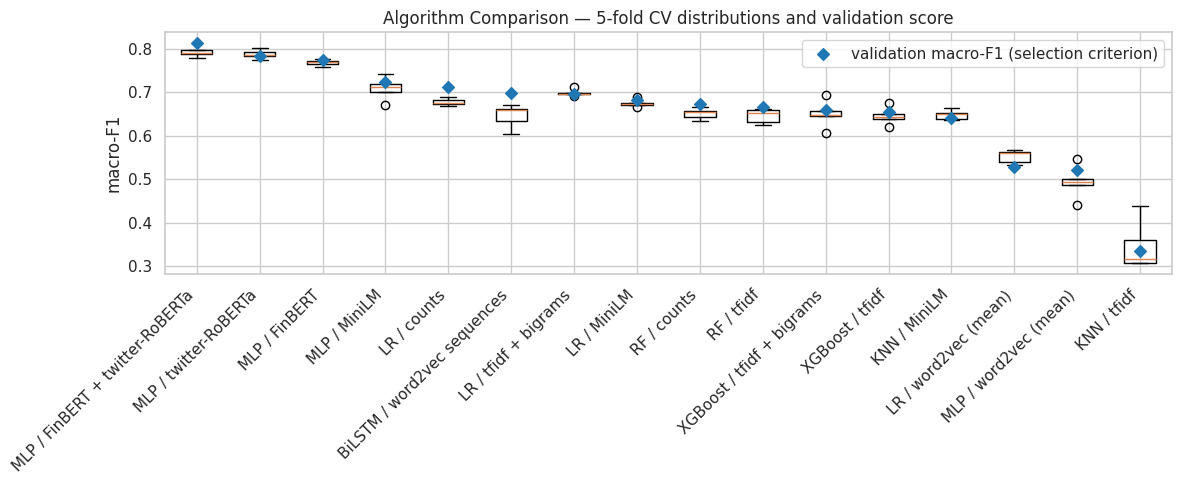

In [36]:
labels = [f"{r.model} / {r.feature}" for r in sweep_df.itertuples()]
plt.figure(figsize=(12, 5))
plt.boxplot([cv_scores_by_model[l] for l in labels], tick_labels=labels)
plt.scatter(range(1, len(labels) + 1), sweep_df["val_macro_f1"], marker="D",
            color="tab:blue", zorder=3, label="validation macro-F1 (selection criterion)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("macro-F1")
plt.title("Algorithm Comparison — 5-fold CV distributions and validation score")
plt.legend(); plt.tight_layout(); plt.show()


**Observations:**

- Transformer-encoder features dominate: the four MLP-on-embeddings models occupy the top four ranks, and concatenating FinBERT with twitter-RoBERTa is the best candidate (CV 0.790 ± 0.007, validation 0.813) — the two domain views are complementary rather than redundant.
- The EDA expectations hold. Lexical baselines are competitive: Logistic Regression reaches validation 0.713 on raw counts and 0.696 on TF-IDF + bigrams. word2vec is the weakest family (validation ≤ 0.53 with both heads), consistent with the antonym-neighbour finding.
- Representation explains the KNN split: 0.335 on sparse TF-IDF (Euclidean distance carries little information in a 4,600-dimensional sparse space) versus 0.641 on dense MiniLM embeddings — same algorithm, different geometry.
- Tree ensembles on sparse text (RF and XGBoost, validation 0.656–0.673) trail the linear model.
- The BiLSTM on word2vec-initialised sequences (validation 0.699, CV 0.647 ± 0.024) reaches the level of the lexical baselines and far exceeds the averaged-word2vec heads (≤0.53): word order recovers much of what mean-pooling destroys. It still trails every pretrained-encoder model (0.723–0.813), the expected limit of training a recurrent model from scratch on 6,679 tweets.
- CV and validation rankings agree at the top, and dispersion among the leading candidates is small (std ≤ 0.009 for the top two; the worst case, 0.051, is the degenerate KNN/tfidf run), so the comparison is stable. The top two candidates proceed to tuning: **MLP on FinBERT + twitter-RoBERTa** and **MLP on twitter-RoBERTa**.


### Hyperparameter Tuning — Top Two

Both finalists are tuned twice — GridSearchCV over a focused grid, RandomizedSearchCV over a wider space — with stratified 5-fold CV macro-F1 on the training split.


In [37]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

FINALISTS = [(r.feature, r.model) for r in sweep_df.head(2).itertuples()]
MODELS_BY = {(f, m): (Xtr, Xv, est) for f, m, Xtr, Xv, est in MODELS}

GRID = {"clf__hidden_layer_sizes": [(256,), (256, 128)],
        "clf__alpha": [1e-4, 1e-3, 1e-2]}
RAND = {"clf__hidden_layer_sizes": [(128,), (256,), (256, 128)],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 5e-4, 3e-4],
        "clf__batch_size": [64, 128, 256]}

TUNED = {}
for feat, model_name in FINALISTS:
    Xtr, Xv, est = MODELS_BY[(feat, model_name)]
    searches = [
        ("grid",   lambda e: GridSearchCV(e, GRID, scoring="f1_macro", cv=skf, n_jobs=-1)),
        ("random", lambda e: RandomizedSearchCV(e, RAND, n_iter=6, scoring="f1_macro",
                                                cv=skf, n_jobs=-1, random_state=RANDOM_STATE)),
    ]
    for search_name, make_search in searches:
        def build(est=est, make_search=make_search, Xtr=Xtr):
            search = make_search(clone(est))
            search.fit(Xtr, y_train)
            return {"best_params": search.best_params_, "cv_best": search.best_score_,
                    "estimator": search.best_estimator_}
        result = load_or_build(f"tuned_{search_name}_{slug(model_name)}_{slug(feat)}.joblib", build)
        label = f"{model_name} / {feat} ({search_name})"
        TUNED[label] = {**result, "X": (Xtr, Xv), "feat": feat, "model": model_name, "search": search_name}
        print(f"{label}\n  CV best {result['cv_best']:.4f}  params {result['best_params']}")


[cache] load  tuned_grid_mlp_finbert_twitter_roberta.joblib
MLP / FinBERT + twitter-RoBERTa (grid)
  CV best 0.7977  params {'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (256,)}
[cache] load  tuned_random_mlp_finbert_twitter_roberta.joblib
MLP / FinBERT + twitter-RoBERTa (random)
  CV best 0.8007  params {'clf__learning_rate_init': 0.0005, 'clf__hidden_layer_sizes': (256,), 'clf__batch_size': 256, 'clf__alpha': 0.0001}
[cache] load  tuned_grid_mlp_twitter_roberta.joblib
MLP / twitter-RoBERTa (grid)
  CV best 0.7964  params {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (256, 128)}
[cache] load  tuned_random_mlp_twitter_roberta.joblib
MLP / twitter-RoBERTa (random)
  CV best 0.7927  params {'clf__learning_rate_init': 0.0005, 'clf__hidden_layer_sizes': (256,), 'clf__batch_size': 64, 'clf__alpha': 0.001}


In [38]:
# Side-by-side train/validation comparison of the tuned finalists
train_cmp, val_cmp = [], []
for label, info in TUNED.items():
    est = info["estimator"]; Xtr, Xv = info["X"]
    train_cmp.append(classification_metrics(y_train, est.predict(Xtr)).T.rename(columns={0: label}))
    val_pred = est.predict(Xv)
    evaluate(y_val, val_pred, info["feat"], f"{info['model']} ({info['search']}-tuned)", show=False)
    val_cmp.append(classification_metrics(y_val, val_pred).T.rename(columns={0: label}))

print("Training performance comparison:")
display(pd.concat(train_cmp, axis=1).round(4))
print("Validation performance comparison:")
pd.concat(val_cmp, axis=1).round(4)


Training performance comparison:


,MLP / FinBERT + twitter-RoBERTa (grid),MLP / FinBERT + twitter-RoBERTa (random),MLP / twitter-RoBERTa (grid),MLP / twitter-RoBERTa (random)
Accuracy,0.9474,0.9154,0.8557,0.8909
Macro Precision,0.9306,0.8882,0.8326,0.8783
Macro Recall,0.9267,0.8837,0.7800,0.8276
Macro F1,0.9286,0.8859,0.8030,0.8503
Weighted F1,0.9474,0.9152,0.8521,0.8884
Balanced Acc,0.9267,0.8837,0.7800,0.8276
MCC,0.8982,0.8359,0.7118,0.7835


Validation performance comparison:


,MLP / FinBERT + twitter-RoBERTa (grid),MLP / FinBERT + twitter-RoBERTa (random),MLP / twitter-RoBERTa (grid),MLP / twitter-RoBERTa (random)
Accuracy,0.8547,0.8624,0.8415,0.8464
Macro Precision,0.8074,0.8174,0.8049,0.8096
Macro Recall,0.8120,0.8176,0.7680,0.7765
Macro F1,0.8092,0.8170,0.7838,0.7910
Weighted F1,0.8551,0.8624,0.8385,0.8439
Balanced Acc,0.8120,0.8176,0.7680,0.7765
MCC,0.7203,0.7339,0.6853,0.6957


**Observations:**

- Tuning adds a small but real gain: the concatenated-embedding MLP improves from validation macro-F1 0.813 (untuned) to **0.817** with the random-search configuration (one hidden layer of 256, alpha 1e-4, learning rate 5e-4, batch size 256; CV best 0.801).
- Random search beats the grid on the winner while overfitting less: training macro-F1 0.886 against 0.929 for the grid-tuned variant, at higher validation score — the wider space found a configuration that generalises better (smaller learning rate, larger batches).
- twitter-RoBERTa alone remains 0.02–0.03 behind the concatenation after tuning (validation 0.784–0.791): the financial-content view of FinBERT adds signal that tweet-register pretraining alone does not capture.
- Train–validation gaps span 0.02–0.12 macro-F1 across the four tuned variants; the concatenated-embedding models overfit most (0.07–0.12), and early stopping keeps the gap bounded.


### Transformer Encoder — Fine-tuned

The frozen-embedding models use the encoder as a feature extractor; here the same twitter-RoBERTa checkpoint is fine-tuned end-to-end with its classification head (3 epochs, learning rate 2e-5, max_length 64, raw text).


In [39]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)

FT_CKPT = EXTRA_ENCODERS["twitter-roberta"]
FT_DIR  = cache_path("finetuned_twitter_roberta")

class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.enc = tokenizer(list(texts), truncation=True, padding=True, max_length=64)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

def finetune_and_predict():
    tok = AutoTokenizer.from_pretrained(FT_CKPT)
    model = AutoModelForSequenceClassification.from_pretrained(FT_CKPT, num_labels=3)
    args = TrainingArguments(
        output_dir=FT_DIR, num_train_epochs=3, learning_rate=2e-5,
        per_device_train_batch_size=32, per_device_eval_batch_size=128,
        weight_decay=0.01, eval_strategy="epoch", save_strategy="no",
        logging_strategy="epoch", report_to=[], seed=RANDOM_STATE,
        use_cpu=not torch.cuda.is_available())
    trainer = Trainer(model=model, args=args,
        train_dataset=TweetDataset(X_train_raw, y_train, tok),
        eval_dataset=TweetDataset(X_val_raw, y_val, tok),
        compute_metrics=lambda p: {"macro_f1": f1_score(p.label_ids, p.predictions.argmax(-1), average="macro")})
    trainer.train()
    model.save_pretrained(FT_DIR); tok.save_pretrained(FT_DIR)   # reload later without retraining
    val_pred = trainer.predict(TweetDataset(X_val_raw, y_val, tok)).predictions.argmax(-1)
    history = [{"epoch": h.get("epoch"), "loss": h.get("loss"), "val_macro_f1": h.get("eval_macro_f1")}
               for h in trainer.state.log_history if "loss" in h or "eval_macro_f1" in h]
    return {"val_pred": val_pred, "history": history}

ft = load_or_build("finetuned_twitter_roberta_val.joblib", finetune_and_predict)
print(pd.DataFrame(ft["history"]).to_string(index=False), "\n")
evaluate(y_val, ft["val_pred"], "raw text", "twitter-RoBERTa fine-tuned")


[cache] load  finetuned_twitter_roberta_val.joblib
 epoch     loss  val_macro_f1
   1.0 0.534814           NaN
   1.0      NaN      0.816103
   2.0 0.290149           NaN
   2.0      NaN      0.843581
   3.0 0.197550           NaN
   3.0      NaN      0.847859 

              precision    recall  f1-score   support

     Bearish       0.76      0.83      0.80       216
     Bullish       0.80      0.87      0.83       289
     Neutral       0.94      0.89      0.92       927

    accuracy                           0.88      1432
   macro avg       0.83      0.86      0.85      1432
weighted avg       0.88      0.88      0.88      1432

Accuracy: 0.8792  |  Macro-F1: 0.8479  |  Balanced acc: 0.8638  |  MCC: 0.7739


np.float64(0.847858663611814)

**Observations:**

- Fine-tuning is the strongest model so far: validation macro-F1 **0.848** (accuracy 0.879), against 0.817 for the best frozen-embedding model — adapting the encoder end-to-end recovers ~3 macro-F1 points over feature extraction from the same checkpoint.
- Per-class performance is the best seen on the minority classes: Bearish recall 0.83 and Bullish recall 0.87, with Neutral F1 at 0.92.
- Validation macro-F1 rose each epoch (0.816 → 0.844 → 0.848) while training loss fell from 0.53 to 0.20; the gain flattens by epoch 3, so the 3-epoch budget is adequate.
- The two `UNEXPECTED` pooler keys in the load report are the checkpoint's unused pooler layer — harmless for sequence classification.


### Conclusion — Classification Models

1. Selected model: **fine-tuned twitter-RoBERTa** (3 epochs, learning rate 2e-5, max_length 64, raw text) — validation macro-F1 0.848, accuracy 0.879, the best of 21 evaluated configurations. Runner-up: random-tuned MLP on concatenated FinBERT + twitter-RoBERTa embeddings (0.817).
2. Rubric coverage: at least two variations of every traditional family — KNN ×2, LR ×4, RF ×2, XGBoost ×2, MLP ×5 — and Transformer Encoders covered in both regimes: six classifiers on frozen encoder features (MiniLM required variation; FinBERT, twitter-RoBERTa and their concatenation from the Extra Work encoders) plus one encoder fine-tuned end-to-end. A BiLSTM over word2vec-initialised sequences completes the representation spectrum, matching the lexical baselines while trailing the pretrained encoders.
3. The Evaluation section reports the full metric table for all models, the finalist's confusion matrices, the one-time internal-test score, and error analysis.
